# NSKT Energy Spectrum Comparison

Compare ground truth and predictions from U-Net, Super SloMo, EDEN, and Ours on NSKT interpolation outputs. The notebook makes two spectrum comparisons:

1. one selected interpolated snapshot from one sample;
2. the time-averaged spectrum across all interpolated snapshots for the same sample.

The current NSKT eval list maps `re_id = 5` to `RE12000`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    import pyfftw
except ImportError:
    pyfftw = None

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "samples").is_dir() and (REPO_ROOT.parent / "samples").is_dir():
    REPO_ROOT = REPO_ROOT.parent

OUTPUT_DIR = REPO_ROOT / "analysis"
OUTPUT_DIR.mkdir(exist_ok=True)

# Saved .npy sample dicts may contain CUDA torch tensors. Force CPU loading
# when NumPy unpickles those tensors through torch.load.
try:
    import torch  # noqa: F401
    import torch.serialization as torch_serialization
except ImportError:
    torch = None
else:
    def _torch_load_cpu(*args, **kwargs):
        kwargs.setdefault("map_location", torch.device("cpu"))
        return torch_serialization.load(*args, **kwargs)

    torch.load = _torch_load_cpu

REPO_ROOT

PosixPath('/pscratch/sd/p/puren93/puren/Interp-DM')

## Configuration

Edit `SAMPLE_INDEX` and `INTERP_STEP_INDEX` to choose the batch element and interpolation step to plot. Both are zero-based indices.

In [2]:
RE_EVAL_LIST = [600, 1000, 2000, 4000, 8000, 12000, 16000, 24000, 32000, 36000]
RE_ID = 5
RE_VALUE = RE_EVAL_LIST[RE_ID]
TOTAL_INTERP_STEPS = 20
MATCH_TOLERANCE = 1e-5

# Batch element and interpolated frame to show in the single-snapshot comparison.
SAMPLE_INDEX = 0
INTERP_STEP_INDEX = 9  # zero-based; 9 means the 10th interpolated snapshot

# Spectrum follows the reference energy_spectrum_from_w implementation.
# Set POWER to 3 or 5 to inspect compensated spectra E(k) * k**POWER.
POWER = 0

SAMPLE_PATHS = {
    "U-Net": REPO_ROOT / f"samples/Model_ft_UNet_Data_nskt_Optim_adam_lr0.0001_epoch200_patchsize256_stride32_T20_TfixedFalse_RE{RE_VALUE}_T{TOTAL_INTERP_STEPS}.npy",
    "Super SloMo": REPO_ROOT / f"samples/Model_SuperSloMo_Data_nskt_Optim_adam_lr6e-05_epoch200_patchsize256_stride32_T20_TfixedTrue_RE{RE_VALUE}_T{TOTAL_INTERP_STEPS}.npy",
    "EDEN": REPO_ROOT / f"samples/EDEN_Data_nskt_patch256_T20_RE{RE_VALUE}_T{TOTAL_INTERP_STEPS}.npy",
    "Ours": REPO_ROOT / f"samples/Model_ft_FLEX_small_mlp2_Data_nskt_Optim_adam_cosine_lr0.0001_epoch300_patchsize256_stride32_T20_TfixedFalse_RE{RE_VALUE}_T{TOTAL_INTERP_STEPS}.npy",
}

for name, path in SAMPLE_PATHS.items():
    print(f"{name:11s}: {path} {'OK' if path.exists() else 'MISSING'}")
    

U-Net      : /pscratch/sd/p/puren93/puren/Interp-DM/samples/Model_ft_UNet_Data_nskt_Optim_adam_lr0.0001_epoch200_patchsize256_stride32_T20_TfixedFalse_RE12000_T20.npy OK
Super SloMo: /pscratch/sd/p/puren93/puren/Interp-DM/samples/Model_SuperSloMo_Data_nskt_Optim_adam_lr6e-05_epoch200_patchsize256_stride32_T20_TfixedTrue_RE12000_T20.npy OK
EDEN       : /pscratch/sd/p/puren93/puren/Interp-DM/samples/EDEN_Data_nskt_patch256_T20_RE12000_T20.npy OK
Ours       : /pscratch/sd/p/puren93/puren/Interp-DM/samples/Model_ft_FLEX_small_mlp2_Data_nskt_Optim_adam_cosine_lr0.0001_epoch300_patchsize256_stride32_T20_TfixedFalse_RE12000_T20.npy OK


## Load Predictions

In [3]:
def to_numpy(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def stack_time_list(items):
    """Convert saved list of T tensors/arrays [B, 1, H, W] into [T, B, H, W]."""
    frames = []
    for item in items:
        arr = to_numpy(item)
        arr = np.squeeze(arr, axis=1) if arr.ndim == 4 and arr.shape[1] == 1 else arr
        frames.append(arr)
    return np.stack(frames, axis=0).astype(np.float64)


def load_sample_file(path):
    try:
        obj = np.load(path, allow_pickle=True).item()
    except ModuleNotFoundError as exc:
        if exc.name == "torch":
            raise ModuleNotFoundError(
                "Loading these saved sample files requires torch because targets were saved as pickled torch tensors. "
                "Run this notebook in the project environment."
            ) from exc
        raise
    targets = stack_time_list(obj["targets"])
    predictions = stack_time_list(obj["predictions"])
    conditioning = to_numpy(obj["conditioning_snapshots"])
    conditioning = np.squeeze(conditioning, axis=1) if conditioning.ndim == 4 and conditioning.shape[1] == 1 else conditioning
    return {
        "conditioning": conditioning.astype(np.float64),
        "targets": targets,
        "predictions": predictions,
    }


missing = [str(path) for path in SAMPLE_PATHS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required sample files:\n" + "\n".join(missing))

samples = {name: load_sample_file(path) for name, path in SAMPLE_PATHS.items()}

batch_sizes = {}
for name, data in samples.items():
    batch_sizes[name] = data["targets"].shape[1]
    print(f"{name:11s} targets={data['targets'].shape}, predictions={data['predictions'].shape}")

print(f"Available batch sizes: {batch_sizes}")

U-Net       targets=(20, 8, 256, 256), predictions=(20, 8, 256, 256)
Super SloMo targets=(20, 64, 256, 256), predictions=(20, 64, 256, 256)
EDEN        targets=(20, 32, 256, 256), predictions=(20, 32, 256, 256)
Ours        targets=(20, 12, 256, 256), predictions=(20, 12, 256, 256)
Available batch sizes: {'U-Net': 8, 'Super SloMo': 64, 'EDEN': 32, 'Ours': 12}


## Validate Alignment

The comparison is meaningful only if each model prediction is paired with the same target snapshot. Since cached files may use different batch sizes and orderings, this cell matches each model's batch element to the selected reference target by minimizing target MAE over all interpolation steps.

In [4]:
REFERENCE_MODEL = "U-Net"
reference_targets = samples[REFERENCE_MODEL]["targets"]
num_steps, reference_batch_size, height, width = reference_targets.shape
if not (0 <= SAMPLE_INDEX < reference_batch_size):
    raise IndexError(f"SAMPLE_INDEX={SAMPLE_INDEX} is outside {REFERENCE_MODEL} batch size {reference_batch_size}")
if not (0 <= INTERP_STEP_INDEX < num_steps):
    raise IndexError(f"INTERP_STEP_INDEX={INTERP_STEP_INDEX} is outside {num_steps} interpolation steps")

ground_truth_sequence = reference_targets[:, SAMPLE_INDEX]
MODEL_SAMPLE_INDEX = {}

for name, data in samples.items():
    targets = data["targets"]
    if targets.shape[0] != num_steps or targets.shape[2:] != (height, width):
        raise ValueError(f"Target time/grid shape mismatch for {name}: {targets.shape} vs {(num_steps, height, width)}")
    distances = np.mean(np.abs(targets - ground_truth_sequence[:, None, :, :]), axis=(0, 2, 3))
    best_idx = int(np.argmin(distances))
    MODEL_SAMPLE_INDEX[name] = best_idx
    max_abs_diff = np.max(np.abs(targets[:, best_idx] - ground_truth_sequence))
    print(
        f"{name:11s} matched batch index {best_idx:3d}: "
        f"target MAE={distances[best_idx]:.6e}, max abs diff={max_abs_diff:.6e}"
    )
    if distances[best_idx] > MATCH_TOLERANCE:
        print(
            f"  WARNING: no exact target match for {name}. "
            "This cached prediction file may not contain the selected reference sample."
        )

print(
    f"Using {REFERENCE_MODEL} sample index {SAMPLE_INDEX} as ground truth, "
    f"interpolation step {INTERP_STEP_INDEX + 1}/{num_steps}, grid {height}x{width}."
)

U-Net       matched batch index   0: target MAE=0.000000e+00, max abs diff=0.000000e+00
Super SloMo matched batch index  23: target MAE=9.038830e+00, max abs diff=5.674744e+01
EDEN        matched batch index  19: target MAE=7.655063e+00, max abs diff=4.563740e+01
Ours        matched batch index   0: target MAE=0.000000e+00, max abs diff=0.000000e+00
Using U-Net sample index 0 as ground truth, interpolation step 10/20, grid 256x256.


## Energy Spectrum Helpers

This follows the reference `energy_spectrum_from_w` implementation: FFT of the vorticity field, `pi * |w_hat|^2 / k`, then annular shell averaging over integer wavenumber bins. If `pyfftw` is available, the notebook uses it; otherwise it falls back to `np.fft.fft2`.

In [5]:
def fft2_reference(field):
    if pyfftw is None:
        return np.fft.fft2(field)

    a = pyfftw.empty_aligned(field.shape, dtype="complex128")
    b = pyfftw.empty_aligned(field.shape, dtype="complex128")
    a[:] = field.astype(np.complex128)
    fft_object = pyfftw.FFTW(a, b, axes=(0, 1), direction="FFTW_FORWARD")
    return fft_object()


def energy_spectrum_from_w(nx, ny, w):
    """Reference vorticity energy spectrum implementation."""
    epsilon = 1.0e-6
    w = np.asarray(w, dtype=np.float64)
    if w.shape != (nx, ny):
        raise ValueError(f"Expected snapshot shape {(nx, ny)}, got {w.shape}")

    dx = 2.0 * np.pi / nx
    dy = 2.0 * np.pi / ny

    kx = np.empty(nx, dtype=np.float64)
    ky = np.empty(ny, dtype=np.float64)
    kx[: int(nx / 2)] = 2 * np.pi / (np.float32(nx) * dx) * np.float32(np.arange(0, int(nx / 2)))
    kx[int(nx / 2) : nx] = 2 * np.pi / (np.float32(nx) * dx) * np.float32(np.arange(-int(nx / 2), 0))
    ky[: int(ny / 2)] = 2 * np.pi / (np.float32(ny) * dy) * np.float32(np.arange(0, int(ny / 2)))
    ky[int(ny / 2) : ny] = 2 * np.pi / (np.float32(ny) * dy) * np.float32(np.arange(-int(ny / 2), 0))
    kx[0] = epsilon
    ky[0] = epsilon

    kx_grid, ky_grid = np.meshgrid(kx, ky, indexing="ij")
    kk = np.sqrt(kx_grid**2 + ky_grid**2)

    wf = fft2_reference(w)
    es = np.pi * ((np.abs(wf) / (nx * ny)) ** 2) / kk

    n = int(np.sqrt(nx * nx + ny * ny) / 2.0) - 1
    en = np.zeros(n + 1, dtype=np.float64)

    for k in range(1, n + 1):
        ii, jj = np.where((kk[1:, 1:] > (k - 0.5)) & (kk[1:, 1:] < (k + 0.5)))
        if ii.size == 0:
            en[k] = np.nan
            continue
        ii = ii + 1
        jj = jj + 1
        en[k] = np.sum(es[ii, jj]) / ii.size

    return en, n


def radial_energy_spectrum(field):
    field = np.asarray(field, dtype=np.float64)
    if field.ndim != 2:
        raise ValueError(f"Expected a 2D snapshot, got shape {field.shape}")
    en, n = energy_spectrum_from_w(field.shape[0], field.shape[1], field)
    k = np.linspace(1, n, n)
    return k, en[1 : n + 1]


def average_spectrum(frames):
    spectra = []
    for frame in frames:
        k, e = radial_energy_spectrum(frame)
        spectra.append(e)
    return k, np.nanmean(np.stack(spectra, axis=0), axis=0)


def collect_single_snapshot_spectra(step_index, sample_index):
    spectra = {}
    k, spectra["Ground truth"] = radial_energy_spectrum(ground_truth_sequence[step_index])
    for name, data in samples.items():
        model_sample_index = MODEL_SAMPLE_INDEX[name]
        _, spectra[name] = radial_energy_spectrum(data["predictions"][step_index, model_sample_index])
    return k, spectra


def collect_time_average_spectra(sample_index):
    spectra = {}
    k, spectra["Ground truth"] = average_spectrum(ground_truth_sequence)
    for name, data in samples.items():
        model_sample_index = MODEL_SAMPLE_INDEX[name]
        _, spectra[name] = average_spectrum(data["predictions"][:, model_sample_index])
    return k, spectra

## Plot Comparisons

Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re12000_energy_spectrum_sample0_step10_power0.pdf
Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re12000_energy_spectrum_sample0_step10_power0.png


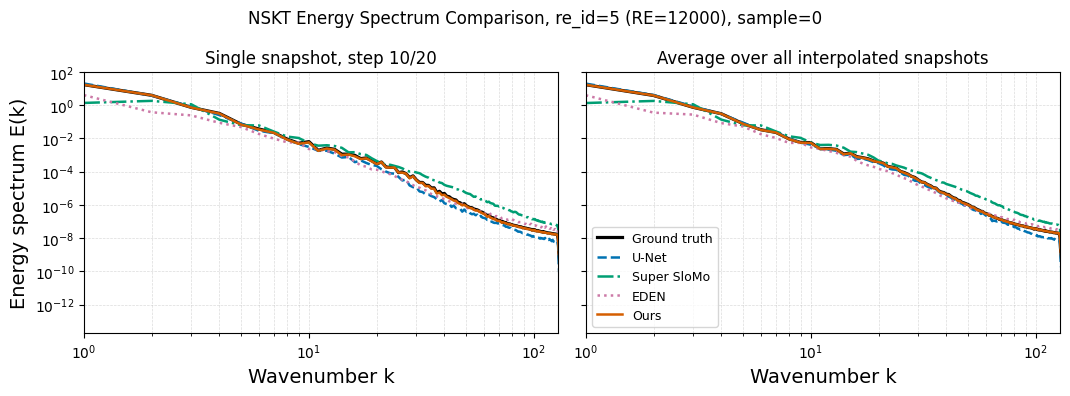

In [6]:
single_k, single_spectra = collect_single_snapshot_spectra(INTERP_STEP_INDEX, SAMPLE_INDEX)
avg_k, avg_spectra = collect_time_average_spectra(SAMPLE_INDEX)

style = {
    "Ground truth": dict(color="black", linewidth=2.3, linestyle="-"),
    "U-Net": dict(color="#0072B2", linewidth=1.8, linestyle="--"),
    "Super SloMo": dict(color="#009E73", linewidth=1.8, linestyle="-."),
    "EDEN": dict(color="#CC79A7", linewidth=1.8, linestyle=":"),
    "Ours": dict(color="#D55E00", linewidth=1.8, linestyle="-"),
}


def plot_spectrum(ax, k, spectrum, label):
    k = np.asarray(k, dtype=np.float64)
    spectrum = np.asarray(spectrum, dtype=np.float64)
    y = spectrum * (k**POWER)
    mask = np.isfinite(k) & np.isfinite(y) & (k > 0) & (y > 0)
    ax.loglog(k[mask], y[mask], label=label, **style.get(label, {}))


fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0), sharey=True)

for label, spectrum in single_spectra.items():
    plot_spectrum(axes[0], single_k, spectrum, label)
axes[0].set_title(f"Single snapshot, step {INTERP_STEP_INDEX + 1}/{num_steps}")
axes[0].set_xlabel("Wavenumber k", fontsize=14)
ylabel = "Energy spectrum E(k)" if POWER == 0 else f"Compensated spectrum E(k) k^{POWER}"
axes[0].set_ylabel(ylabel, fontsize=14)

for label, spectrum in avg_spectra.items():
    plot_spectrum(axes[1], avg_k, spectrum, label)
axes[1].set_title("Average over all interpolated snapshots")
axes[1].set_xlabel("Wavenumber k", fontsize=14)

max_resolved_k = min(height, width) // 2
for ax in axes:
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.45)
    ax.set_xlim(1, max_resolved_k)

axes[1].legend(loc="best", frameon=True, fontsize=9)
fig.suptitle(f"NSKT Energy Spectrum Comparison, re_id={RE_ID} (RE={RE_VALUE}), sample={SAMPLE_INDEX}")
fig.tight_layout()

figure_stem = f"nskt_re{RE_VALUE}_energy_spectrum_sample{SAMPLE_INDEX}_step{INTERP_STEP_INDEX + 1}_power{POWER}"
pdf_path = OUTPUT_DIR / f"{figure_stem}.pdf"
png_path = OUTPUT_DIR / f"{figure_stem}.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved {pdf_path}")
print(f"Saved {png_path}")

plt.show()

Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re12000_energy_spectrum_average_sample0_power0.pdf
Saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re12000_energy_spectrum_average_sample0_power0.png


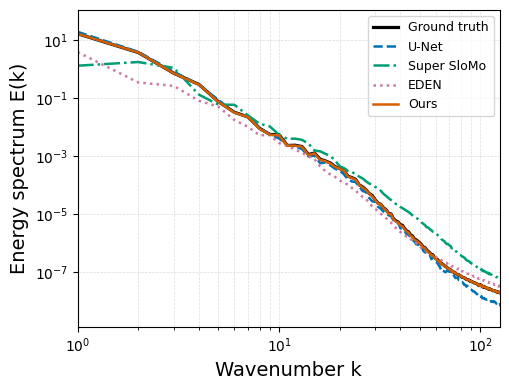

In [9]:
# Average-only spectrum plot across all interpolated snapshots.
avg_k, avg_spectra = collect_time_average_spectra(SAMPLE_INDEX)

fig, ax = plt.subplots(figsize=(5.2, 4.0))

for label, spectrum in avg_spectra.items():
    plot_spectrum(ax, avg_k, spectrum, label)

# ax.set_title("Average over all interpolated snapshots")
ax.set_xlabel("Wavenumber k", fontsize=14)
ylabel = "Energy spectrum E(k)" if POWER == 0 else f"Compensated spectrum E(k) k^{POWER}"
ax.set_ylabel(ylabel, fontsize=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.45)
max_resolved_k = min(height, width) // 2
display_max_k = max(2, int(max_resolved_k * 0.98))
ax.set_xlim(1, display_max_k)

visible_y_values = []
for spectrum in avg_spectra.values():
    k = np.asarray(avg_k, dtype=np.float64)
    y = np.asarray(spectrum, dtype=np.float64) * (k**POWER)
    visible_mask = np.isfinite(k) & np.isfinite(y) & (k >= 1) & (k <= display_max_k) & (y > 0)
    if np.any(visible_mask):
        visible_y_values.append(y[visible_mask])

if visible_y_values:
    visible_y_values = np.concatenate(visible_y_values)
    log_y_min, log_y_max = np.log10([visible_y_values.min(), visible_y_values.max()])
    log_pad = max(0.08 * (log_y_max - log_y_min), 0.15)
    ax.set_ylim(10 ** (log_y_min - log_pad), 10 ** (log_y_max + log_pad))
ax.legend(loc="best", frameon=True, fontsize=9)

fig.tight_layout()

figure_stem = f"nskt_re{RE_VALUE}_energy_spectrum_average_sample{SAMPLE_INDEX}_power{POWER}"
pdf_path = OUTPUT_DIR / f"{figure_stem}.pdf"
png_path = OUTPUT_DIR / f"{figure_stem}.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

print(f"Saved {pdf_path}")
print(f"Saved {png_path}")

plt.show()